# CAPSTONE Project Artificial Intelligence 

We want to build a machine learning model on _fashion_mnist_ dataset. We will Create a Classification Deep learning model using Keras/Tensorflow framework, but before that we will start with a **simple feeward neural network**, then we will move on a **convolutional neural network** that will be our base model, and finally we will build our **final convolutional neural network model**.

Instead of downloading data from https://github.com/zalandoresearch/fashion-mnist , we will use the one integrated into keras.datasets package. Just to precise that fashion_mnist dataset is compose of _training_ and _test_ dataset of images in greyscale color. Each picture is 28 x 28 shape [pixels]. Training dataset has 60 000 images (60 000 * 28 * 28 shape) and test dataset has 10 000 images (10 000 * 28 * 28 shape). The data is labelised.

The **Goal** is to build a model that can help us classify any images among the 10 identified classes. 

What we will use:
-1. Convolutional Neural Network
-2. Visualisation of the Error/Accuracy with Tensorboard.
-3. Model saving and best weights saving.
-4. Calculation of the accuracy on Test dataset.

In [6]:
# 1. Define a log directory
import os
from datetime import datetime
import tensorflow as tf

log_dir = "logs/run_" + datetime.now().strftime("%Y%m%d-%H%M%S")
os.makedirs(log_dir, exist_ok=True)

print(f"Created log directory: {log_dir}")

Created log directory: logs/run_20260819-012143


In [25]:
# 2. Create a dummy summary file (This is the key step!)
writer = tf.summary.create_file_writer(log_dir)
with writer.as_default():
    tf.summary.scalar('dummy', 1.0, step=1)

print(f"Written dummy event file to: {log_dir}")


Created log directory: logs/run_20260817-125416
Written dummy event file to: logs/run_20260817-125416


In [26]:
import os
os.environ['PATH'] += os.pathsep + '.venv/bin'

In [27]:
# Load the tensorBoard notebook extension
%load_ext tensorboard
%tensorboard --logdir {log_dir} # the path of the logs directory
    

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


## Simple Neural Network

In [39]:
# we import tensorflow
import tensorflow as tf

In [40]:
# we import the dataset fashion_mnist module
from keras.datasets import fashion_mnist

In [41]:
# we load the dataset and make sure he has the rigth shape
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
assert x_train.shape == (60000, 28, 28)
assert x_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)

In [42]:
import pandas as pd
import numpy as np

<Axes: xlabel='class', ylabel='count'>

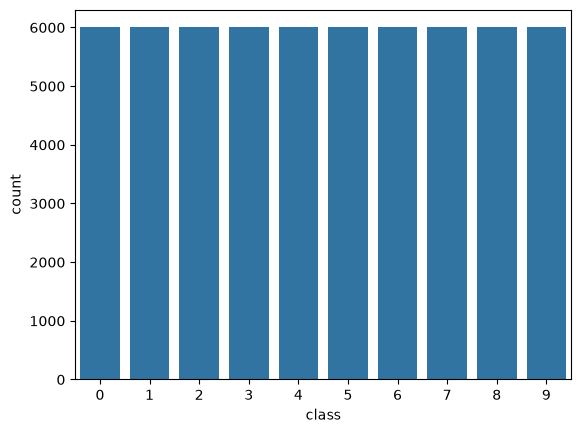

In [43]:
import seaborn as sn
sn.countplot(x='class', data = pd.DataFrame(data=y_train, columns=['class']))
# we can notice that label is evenly distributed in train and test data
# in that case we can use accuracy or F1 as metrics for learning apreciation

<Axes: xlabel='class', ylabel='count'>

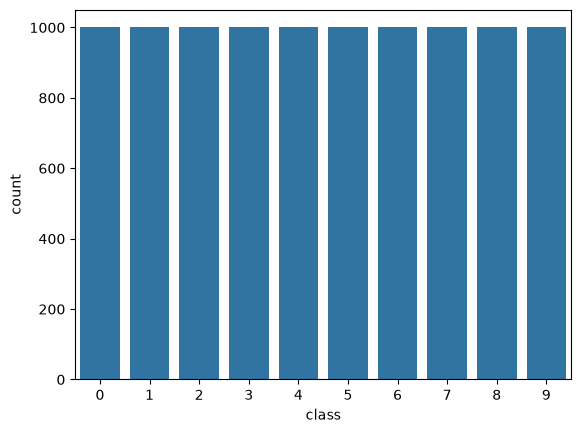

In [44]:
import seaborn as sn
sn.countplot(x='class', data = pd.DataFrame(data=y_test, columns=['class']))
# we can notice that labels is evenly distributed in test data

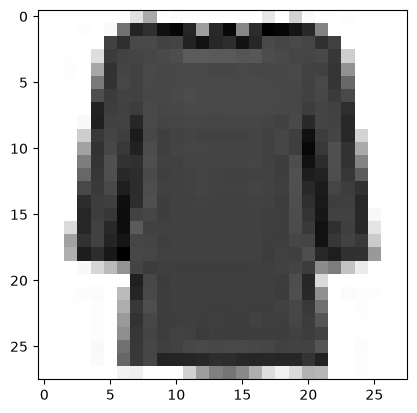

In [45]:
# display the 157th image

digit = x_train[157] # take the 157th image
import matplotlib.pyplot as plt # import the matplotlib package
plt.imshow(digit, cmap=plt.cm.binary)
plt.show()

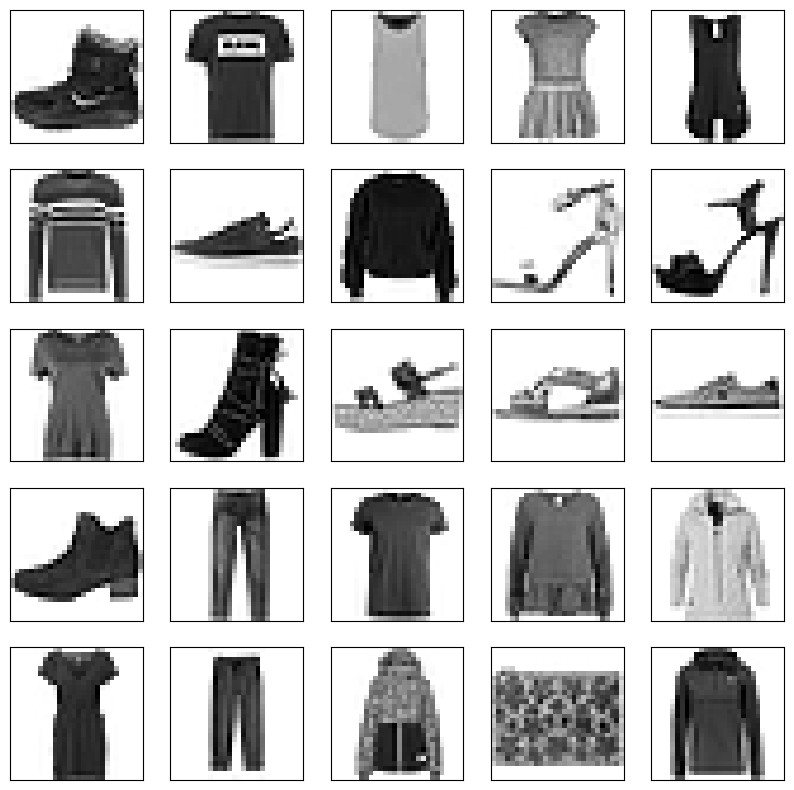

In [46]:
# plot 25 first image of the dataset
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))  # define the heigth and width of whole picture
for i in range(25):          # across the each of the 25 first images
    plt.subplot(5,5,i+1)     # plot that image with 5 * 5 dimensions
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
plt.show()

In [47]:
# Prepare the image data
x_train = x_train.reshape((60000, 28 * 28)) # reshape data in the shape fitting the network
x_train = x_train.astype('float32') / 255   # scaling the data between 0 - 1

x_test = x_test.reshape((10000, 28 * 28)) # reshape data in the shape fitting the network
x_test = x_test.astype('float32') / 255   # scaling the data between 0 - 1

# Preparing the labels

from keras.utils import to_categorical

y_train = to_categorical(y_train, 10) # categorise the label that is number initialy, we will have shape (60k, 10) [hot encoding] and not (10k,)
y_test = to_categorical(y_test, 10)   # categorise the label that is number initialy, we will have shape (10k, 10) [hot encoding] and not (10k,)

In [48]:
# the architercture network
from keras import models  # import models from keras
from keras import layers  # import layers from keras

# ANN model
# each image is 28 * 28 = 784 pixels, this is the input shape
# the activation function ReLU (Rectified Linear Unit) [introduce non linearity] f(x) = max(0, x) allow the neuron to learn complex pattern unless it would be just linear
# 512 is the number of neurons that learn omplex feature combination [512 biases] 
# 10 is the number of class
# the activation function softmax softmax(x_i) = e^(x_i) / Σ(e^(x_j)) for all j will give the probabilities to belong to one class

network = models.Sequential() # sequential model

# Add explicit Input layer first for recent version of Keras
# network.add(keras.Input(shape=(28 * 28,))) 

network.add(layers.Dense(512, 
                         activation='relu', 
                         input_shape=(28 * 28,), 
                         kernel_initializer='he_normal',  # Explicitly sets weights ~ N(0, sqrt(2/fan_in)) 2/784 = 
                         bias_initializer='zeros'         # Biases start at 0
                        )) # first layer (input one) with relu activation function and 512 output point
network.add(layers.Dense(10, 
                         activation='softmax',
                         kernel_initializer='glorot_uniform', # Default, good for sigmoid/tanh/softmax
                         bias_initializer='zeros')) # last and output layer with softmax function activation and 10 output that corresponds to 10 labels

# compilation step
network.compile(optimizer='rmsprop',
                loss='categorical_crossentropy', # cost function is categorical crossentropy or 'sparse_categorical_crossentropy' if labels are integers
                metrics=['accuracy'])            # metric use to improve learning is accuracy

/home/bomyr/Documents/BK_Projects/CNN_mnist/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [49]:
# fit the model 
# epoch is the number of time the algorithm see the entire dataset
# batch_size is the number of sample processed before updated its weigths
network.fit(x_train, y_train, epochs=5, batch_size=128)

# evaluate
test_loss, test_acc = network.evaluate(x_test, y_test) # use the model on test data

print('test_acc:', test_acc)  # print the accuracy on test data

Epoch 1/5


W0000 00:00:1786988721.916911  459990 cpu_allocator_impl.cc:82] Allocation of 188160000 exceeds 10% of free system memory.


469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8027 - loss: 0.5554
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8616 - loss: 0.3813
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8760 - loss: 0.3378
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8837 - loss: 0.3127
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8923 - loss: 0.2917
 31/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8821 - loss: 0.3328   

W0000 00:00:1786988747.856558  459990 cpu_allocator_impl.cc:82] Allocation of 31360000 exceeds 10% of free system memory.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8787 - loss: 0.3367
test_acc: 0.8787000179290771


In [51]:
network.save('./model/fashion_mnist_1.h5') # save the model
network.save('./model/fashion_mnist_1.keras')

## Base Convolutional Neural Network

In [52]:
# we import tensorflow
import tensorflow

In [53]:
tf.keras.preprocessing.image.ImageDataGenerator

keras.src.legacy.preprocessing.image.ImageDataGenerator

In [54]:
# load the dataset module
from keras.datasets import fashion_mnist

In [55]:
# as previously, load the dataset and check shape
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
assert x_train.shape == (60000, 28, 28)
assert x_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)

<Axes: xlabel='class', ylabel='count'>

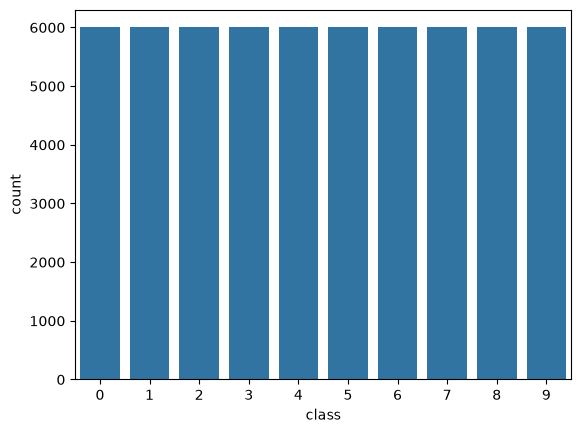

In [56]:
import seaborn as sn
sn.countplot(x='class', data = pd.DataFrame(data=y_train, columns=['class']))
# we can notice that label is evenly distributed in train and test data
# in that case we can use accuracy  as metrics for learning apreciation

<Axes: xlabel='class', ylabel='count'>

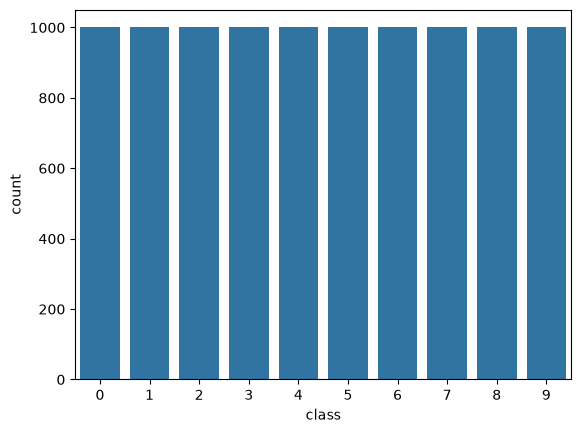

In [57]:
import seaborn as sn
sn.countplot(x='class', data = pd.DataFrame(data=y_test, columns=['class']))
# we can notice that label is evenly distributed in train and test data
# in that case we can use accuracy  as metrics for learning apreciation

In [58]:
# reshape data in the shape fitting the network, here we end with a tensor of 4D
x_train = x_train.reshape((60000, 28, 28, 1))
x_test = x_test.reshape((10000, 28, 28, 1))

# we categorise label
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [59]:
# use of ImageDataGenerator to preprocess the image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale = 1./255, # scaling the data btw 0-1
    validation_split=0.25) # split data in training .75 and validation part .25

# Convolutionnal model from scratch
model = models.Sequential() # sequential model
model.add(layers.Conv2D(filters=32, kernel_size =(3, 3), activation='relu', input_shape = (28, 28, 1))) # input layer, convolutionnal, with 32 filters of size 3 * 3
model.add(layers.MaxPooling2D((2, 2))) # max pool layer
model.add(layers.Conv2D(64, (3, 3), activation='relu')) # convolutionnal with 64 filter and 3 * 3 size' filter
model.add(layers.MaxPooling2D((2, 2)))  # maxpooling layer
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

/home/bomyr/Documents/BK_Projects/CNN_mnist/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [61]:
# add classifier on top
model.add(layers.Flatten())    # flatten layer
model.add(layers.Dense(64, activation='relu')) # dense layer with relu activation
model.add(layers.Dense(10, activation='softmax')) # output layer with softmax function and 10 outputs (labels)

In [62]:
model.summary() # get the summary of the model

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,676 (369.83 KB)

 Trainable params: 94,676 (369.83 KB)

 Non-trainable params: 0 (0.00 B)

In [63]:
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [64]:
# fitting the model using batch generator
history = model.fit(
    datagen.flow(x_train, y_train, subset='training', batch_size = 60),
    steps_per_epoch=750,
    epochs=15,
    validation_data=datagen.flow(x_train, y_train, subset= 'validation', batch_size=40),
    validation_steps=375)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.5457 - loss: 1.2144 - val_accuracy: 0.7562 - val_loss: 0.6887
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.7915 - loss: 0.5601 - val_accuracy: 0.8175 - val_loss: 0.4651
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.8426 - loss: 0.4282 - val_accuracy: 0.8651 - val_loss: 0.4004
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.8801 - loss: 0.3525 - val_accuracy: 0.8885 - val_loss: 0.3325
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.8928 - loss: 0.3120 - val_accuracy: 0.8901 - val_loss: 0.3223
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 57ms/step - accuracy: 0.9027 - loss: 0.2823 - val_accuracy: 0.8971 - val_loss: 0.3016
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 56s 74ms/step - accuracy: 0.9108 - loss: 0.2570 - val_accuracy: 0.8906 - val_loss: 0.3092
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 70s 94ms/step - accuracy: 0.9177 - loss: 0.2363 - 

In [65]:
# evaluate the model on test data
test_loss, test_acc = model.evaluate(x_test, y_test)

print(test_acc)

# save the model
model.save('./models/fashion_mnist_2.h5')
model.save('./models/fashion_mnist_2.keras')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5200 - loss: 5.2756


0.5199999809265137


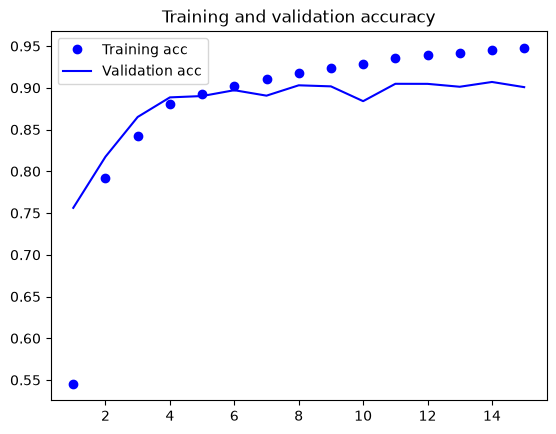

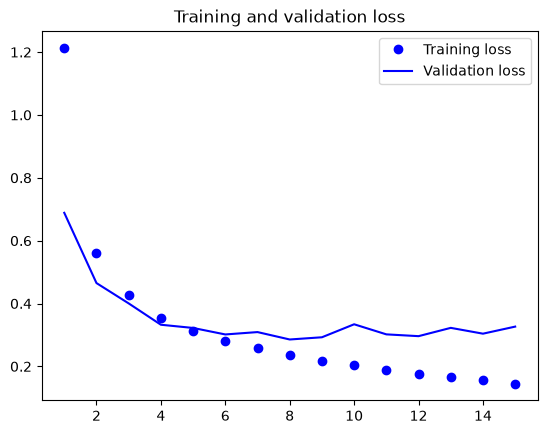

In [66]:
# Displaying curves of loss and accuracy during training

import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

##  Convolutional Neural Network with improved parameters

In [88]:
import os
from datetime import datetime
import tensorflow as tf
import pandas as pd
import seaborn as sn
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import TensorBoard, ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn import model_selection
from tensorflow.keras.optimizers import SGD
from keras.datasets import fashion_mnist
from keras.utils import plot_model
import visualkeras
from matplotlib import pyplot as plt


In [89]:
# 2. Define log directory
log_dir = "logs/run_" + datetime.now().strftime("%Y%m%d-%H%M%S")
os.makedirs(log_dir, exist_ok=True)
print(f"Created log directory: {log_dir}")

Created log directory: logs/run_20260819-185740


In [90]:
# if necessary in jupyterlab
os.environ['PATH'] += os.pathsep + '.venv/bin'

In [91]:
# 3. Load TensorBoard extension (MUST be after log_dir creation)
%load_ext tensorboard
%tensorboard --logdir {log_dir}

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [92]:
# load dataset
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
# summarise loaded dataset
print('Train: X:%s, y=%s' % (train_images.shape, train_labels.shape))
print('Test: X:%s, y=%s' % (test_images.shape, test_labels.shape))

Train: X:(60000, 28, 28), y=(60000,)
Test: X:(10000, 28, 28), y=(10000,)


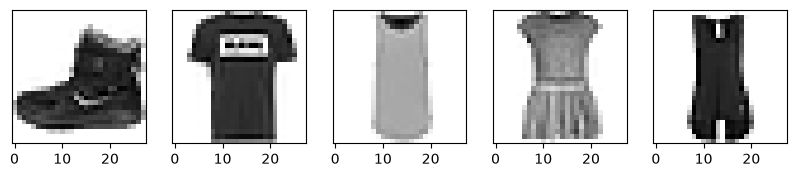

In [93]:
import matplotlib.pyplot as plt

# plot few images
plt.figure(figsize=(10,10))
for i in range(5):
    plt.subplot(1,5,i+1)
    #plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
plt.show()

<Axes: xlabel='class', ylabel='count'>

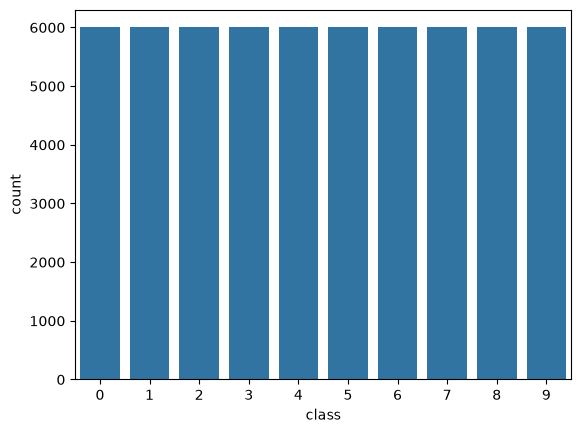

In [94]:

sn.countplot(x='class', data = pd.DataFrame(data=train_labels, columns=['class']))
# we can notice that label is evenly distributed in train and test data

<Axes: xlabel='class', ylabel='count'>

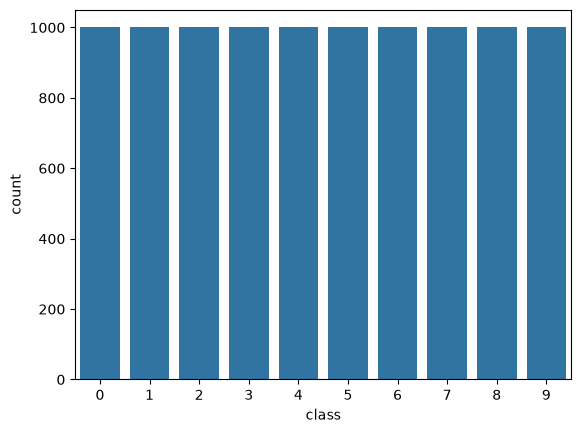

In [95]:
sn.countplot(x='class', data = pd.DataFrame(data=test_labels, columns=['class']))
# we can notice that label is evenly distributed in train and test data

In [96]:
# we can notice that label is evenly distributed in train and test data
# in that case we can use accuracy  as metrics for learning apreciation
# this is a crucial step in classification problem, identify the metric

In [97]:
# define load and preprocess function
def load_format_dataset():
    # load data set
    (train_X, train_y), (test_X, test_y) = fashion_mnist.load_data()
    # reshape the data 
    train_X = train_X.reshape(train_X.shape[0], 28, 28, 1) # train_X[0] is the number of training sample
    test_X  = test_X.reshape(test_X.shape[0], 28, 28, 1)   # test_y[0] is the number of test sample
    # one hot encoding of targer=t values (10)
    train_y = to_categorical(train_y)
    test_y = to_categorical(test_y)
    # return train data and test data in the rigth format
    return train_X, train_y, test_X, test_y

# scale images    
def preprocess_images(train_X, test_X):
    # convert from intergers to float
    train_nom = train_X.astype('float32')
    test_nom  = test_X.astype('float32')
    # normalise range 0 - 1
    train_nom = train_nom * 1. / 255.
    test_nom = test_nom * 1. / 255.
    # return normalised images
    return train_nom, test_nom

# Add this as the FIRST layer in specify_model()
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

# define the model
def specify_model():   
    model = models.Sequential()
    model.add(keras.Input(shape=(28, 28, 1)))
    # model.add(data_augmentation)
    # 1st layer input : 2D convolutional with kernel size as 3*3 and Max pooling operation
    model.add(layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    # 2nd layer hidden: 2D convolutionnal with kernel size 3*3 Relu activation  and max pooling
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.2)) # this will "delete" 25 % of result of previous layers, the goal is to regularise learnnig process
    # 3rd layer hidden: 2D convolutionnal with kernel size 3*3 Relu activation  and max pooling
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))
    # Fully connected layer with Relu activation 
    model.add(layers.Flatten())
    model.add(layers.Dropout(0.02))
    model.add(layers.Dense(512, activation='relu', kernel_initializer='he_uniform'))
    # output layer
    model.add(layers.Dense(10, activation='softmax'))
    # compile
    model.compile(
        optimizer=SGD(learning_rate=0.01, momentum=0.9), # we change the optimizer of previous model
        loss='categorical_crossentropy', 
        metrics=['accuracy'])
    
    return model

In [98]:
# define the cross validation approach Kfold

def cross_validation(data_X, data_y, n_folds=5):
    scores, histories = list(), list()
    # initiate the kfold class from model_selection module
    kfold = model_selection.KFold(n_folds, shuffle = True, random_state=1987)
    # enumarate splits
    for fold_idx, (trn_, val_) in enumerate(kfold.split(X=data_X)):
        #  Create unique log dir per fold
        fold_log_dir = os.path.join(log_dir, f"fold_{fold_idx}")
        os.makedirs(fold_log_dir, exist_ok=True)
        
        # instantiate the model
        convnet = specify_model()
        # select row for train and validation
        train_X, train_y, val_X, val_y = data_X[trn_], data_y[trn_], data_X[val_], data_y[val_]
        # details records
        tensorboard_callback = TensorBoard(
            log_dir=fold_log_dir, 
            histogram_freq=1,      #  Weight/activation histograms every epoch
            write_graph=True,      #  Model architecture visualization
            write_images=True,     #  Weights as images
            update_freq='epoch',   #  Metrics logged every epoch
            profile_batch=0,       #  Performance profiling of batch 2
            embeddings_freq=1      #  Embedding visualizations (if applicable)
        )
        # checkpoint
        filepath=f"./models/group_3/fold_{fold_idx}_weights.best.keras"
        checkpoint = ModelCheckpoint(filepath, monitor='val_accuracy', verbose=1, 
                                     save_best_only=True, mode='max')
        
        # early stopping
        es = EarlyStopping(monitor='val_accuracy', patience=5, mode='max', restore_best_weights=True)
        
        # fit the model
        history = convnet.fit(train_X, train_y, epochs = 10, batch_size = 32, 
                              validation_data = (val_X, val_y),
                              callbacks=[tensorboard_callback, checkpoint, es], 
                              verbose =0 )
        # evaluate model
        _, acc = convnet.evaluate(val_X, val_y)
        print(f'Fold {fold_idx + 1}: > %.3f' % (acc * 100.0))
        scores.append(acc)
        histories.append(history)
        
    return  scores, histories, convnet

In [99]:
# plot curves
def summarise_learning(histories):
    n_folds = len(histories)
    
    # Create ONE figure with enough subplots for ALL folds
    # 2 rows (Acc, Loss) x n_folds columns
    fig, axs = plt.subplots(2, n_folds, figsize=(5 * n_folds, 8))
    
    for i in range(n_folds):
        epochs = range(1, len(histories[i].history['accuracy']) + 1)
        
        # --- Row 1: Accuracy ---
        # Handle case where n_folds=1 (axs is not a list)
        ax_acc = axs[0] if n_folds == 1 else axs[0, i]
        
        ax_acc.plot(histories[i].history['accuracy'], 'bo-', label='Train Acc')
        ax_acc.plot(histories[i].history['val_accuracy'], 'g-', label='Val Acc')
        ax_acc.set_title(f'Fold {i+1}: Accuracy')
        ax_acc.set_xlabel('Epoch')
        ax_acc.set_ylabel('Accuracy')
        ax_acc.legend(loc='lower right')
        ax_acc.grid(True, alpha=0.3)

        # --- Row 2: Loss ---
        ax_loss = axs[1] if n_folds == 1 else axs[1, i]
        
        ax_loss.plot(histories[i].history['loss'], 'bo-', label='Train Loss')
        ax_loss.plot(histories[i].history['val_loss'], 'g-', label='Val Loss')
        ax_loss.set_title(f'Fold {i+1}: Loss')
        ax_loss.set_xlabel('Epoch')
        ax_loss.set_ylabel('Loss')
        ax_loss.legend(loc='upper right')
        ax_loss.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [100]:
# summarising performance
from numpy import mean, std
def summarise_performance (scores):
    # print summary
    print(f'Accuracy: mean = {mean(scores)*100:.3f}%, std = {std(scores)*100:.3f}%')
    
    plt.figure(figsize=(6, 4))
    plt.boxplot(scores)
    plt.title('Model Performance Distribution (K-Fold)')
    plt.ylabel('Accuracy')
    plt.xticks([1], ['K-Fold'])
    plt.grid(True, axis='y', alpha=0.3)
    plt.show()
    

In [101]:
# load data setfold_idx, (
trainX, trainY, testX, testY = load_format_dataset()
# prepare images
trainX, testX = preprocess_images(trainX, testX)
# evaluate
scores, histories, convnet_fmnist = cross_validation(trainX, trainY)   


Epoch 1: val_accuracy improved from None to 0.87158, saving model to ./models/group_3/fold_0_weights.best.keras

Epoch 1: finished saving model to ./models/group_3/fold_0_weights.best.keras

Epoch 2: val_accuracy improved from 0.87158 to 0.88858, saving model to ./models/group_3/fold_0_weights.best.keras

Epoch 2: finished saving model to ./models/group_3/fold_0_weights.best.keras

Epoch 3: val_accuracy improved from 0.88858 to 0.89775, saving model to ./models/group_3/fold_0_weights.best.keras

Epoch 3: finished saving model to ./models/group_3/fold_0_weights.best.keras

Epoch 4: val_accuracy improved from 0.89775 to 0.90683, saving model to ./models/group_3/fold_0_weights.best.keras

Epoch 4: finished saving model to ./models/group_3/fold_0_weights.best.keras

Epoch 5: val_accuracy improved from 0.90683 to 0.90708, saving model to ./models/group_3/fold_0_weights.best.keras

Epoch 5: finished saving model to ./models/group_3/fold_0_weights.best.keras

Epoch 6: val_accuracy improved f

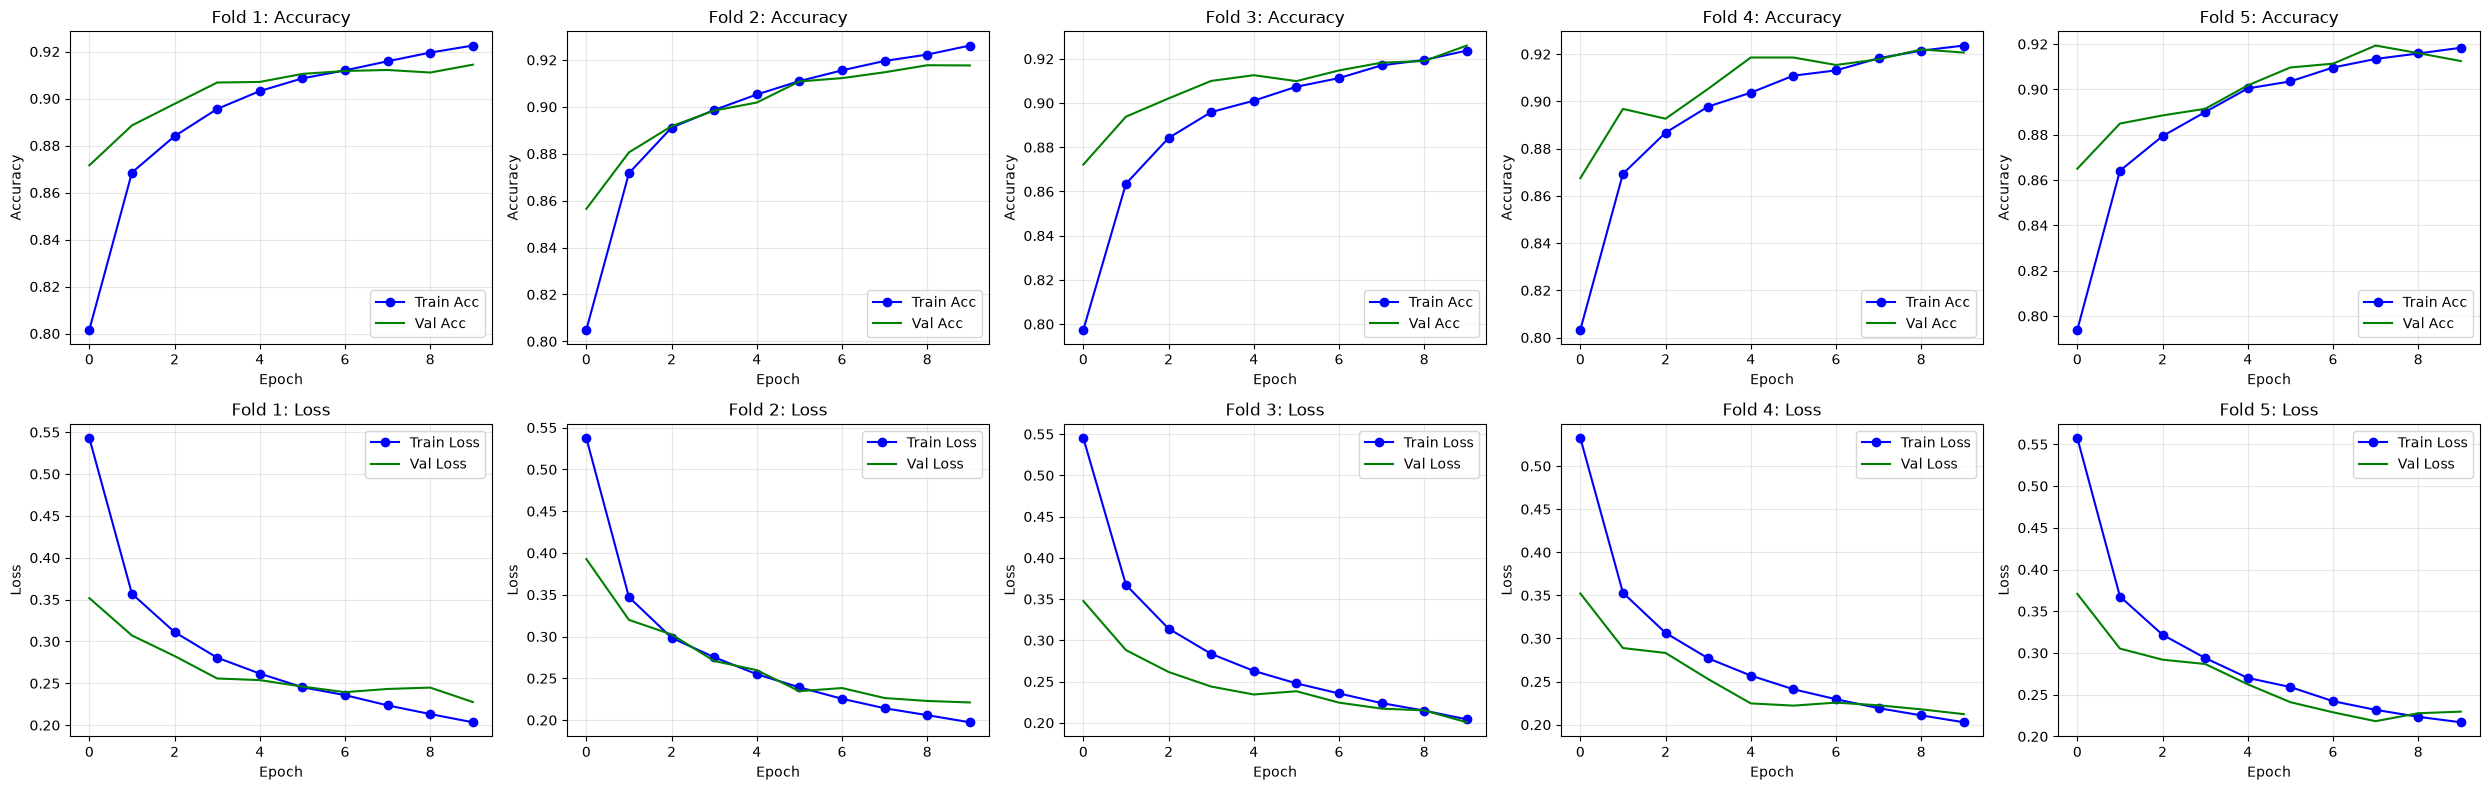

Accuracy: mean = 91.990%, std = 0.391%


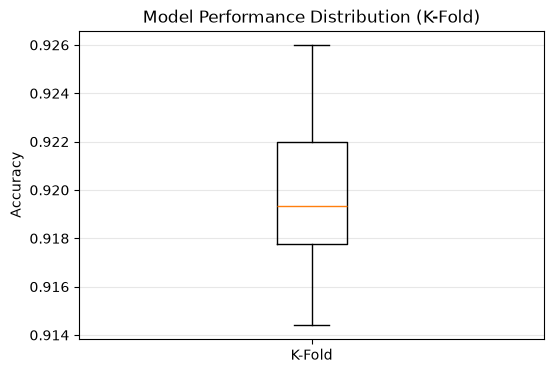

In [102]:
# learning curves
summarise_learning(histories)
# summarise perform
summarise_performance(scores)

In [103]:
# 1. VisualKeras (Best for CNNs)
visualkeras.layered_view(convnet_fmnist, legend=True, 
                         to_file='./image/model_f_1.png')


/home/bomyr/Documents/BK_Projects/CNN_mnist/.venv/lib/python3.11/site-packages/visualkeras/layered.py:231: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


AttributeError: 'Conv2D' object has no attribute 'output_shape'

In [ ]:
# save image model
tf.keras.utils.plot_model(convnet_fmnist, to_file='./image/model_f_2.png',
                          show_shapes=True, show_layer_names=True, rankdir='TB')

In [ ]:
# save image model
tf.keras.utils.plot_model(convnet_fmnist, to_file='./image/model_f_3.png',
                          show_layer_activations=True)

In [ ]:
# save image model
tf.keras.utils.plot_model(convnet_fmnist, to_file='./image/model_f_4.png',
                          expand_nested=True, show_shapes=True, rankdir='LR')

In [ ]:
# save the model
# Save Model (Use modern .keras format)
convnet_fmnist.save('./models/fashion_mnist_best.keras')

In [ ]:
test_loss, test_acc = convnet_fmnist.evaluate(testX,  testY, verbose=2)

print('\nTest accuracy:', test_acc)

In [ ]:
#add a softmax layer to have probability results
# Probability Model
probability_model = tf.keras.Sequential([
    convnet_fmnist, 
    tf.keras.layers.Softmax()
])

In [81]:
# Optional: Save probability model too
probability_model.save('./models/fashion_mnist_probability.keras')